# Fase 3 — NLP (BERT) + LLM para análisis de contexto (Curso 107071)

Este notebook produce:
1) Carga de metadatos (Scopus/WoS exportado .csv con abstracts).
2) Análisis de sentimiento con modelo multilingüe tipo BERT (Transformers).
3) Gráfico de sentimiento promedio por año.
4) Análisis de contexto con un LLM open source liviano para extraer inteligencia estratégica.

> Para bibliometría (co-citación y mapa temático) usarás Biblioshiny (R). Aquí nos enfocamos en NLP/LLM.


In [ ]:
!pip -q install transformers accelerate sentencepiece pandas matplotlib

In [ ]:
import os, glob

# lista archivos CSV en tu Drive (puede tardar unos segundos)
paths = glob.glob("/content/drive/MyDrive/**/*.csv", recursive=True)

print("CSV encontrados:", len(paths))
for p in paths[:30]:
    print(p)

CSV encontrados: 0


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
import torch

SEED = 42
rng = np.random.default_rng(SEED)


## 1) Cargar metadatos (CSV con abstracts)
Exporta desde Scopus/WoS un CSV que incluya año y abstract.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# TODO: cambia esta ruta al CSV exportado
CSV_META = "/content/drive/MyDrive/FASE3/scopus_export.csv"

df = pd.read_csv(CSV_META)
print(df.shape)
df.head(3)


Mounted at /content/drive
(349, 12)


,Authors,Author full names,Author(s) ID,Year,Source title,Cited by,DOI,Link,Affiliations,Authors with affiliations,Abstract,Author Keywords
0,Fuertes-Alpiste M.,"Fuertes-Alpiste, Marc (57195286534)",57195286534,2025,Revista Espanola de Educacion Comparada,1,10.5944/reec.48.2025.45379,https://www.scopus.com/pages/publications/1050...,Departamento de Teoría e Historia de la Educac...,"Fuertes-Alpiste M., Departamento de Teoría e H...",The emergence of generative artificial intelli...,activity theory; artificial intelligence; cogn...
1,Londoño Villarreal L.F.,"Londoño Villarreal, Luis Felipe (60117326800)",60117326800,2025,Revista Criminalidad,0,10.47741/17943108.731,https://www.scopus.com/pages/publications/1050...,"Universidad del Rosario, Bogotá, Colombia","Londoño Villarreal L.F., Universidad del Rosar...",This article analyses the regulatory and ethic...,access to justice; AI regulation; artificial i...
2,Avello-Sáez D.; Lucero-González N.; Villagrán I.,"Avello-Sáez, Daniela (57193953662); Lucero-Gon...",57193953662; 57706525300; 57203803023,2024,Revista Medica Clinica Las Condes,4,10.1016/j.rmclc.2024.06.003,https://www.scopus.com/pages/publications/8520...,"Departamento de Terapia Ocupacional, Escuela d...","Avello-Sáez D., Departamento de Terapia Ocupac...","Introduction: Artificial intelligence (AI), th...",Academic Integrity; Artificial Intelligence; C...


### Normaliza columnas (año y abstract)
Ajusta los nombres según tu exportación (Year/PY y Abstract/AB).


In [ ]:
# TODO: ajusta nombres reales
COL_YEAR = "Year"
COL_ABS = "Abstract"

df = df.rename(columns={COL_YEAR: "year", COL_ABS: "abstract"}).copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["abstract"] = df["abstract"].astype(str).fillna("")
df = df.dropna(subset=["year"])
df = df[df["abstract"].str.len() > 30]

df[["year","abstract"]].head(3)


,year,abstract
0,2025,The emergence of generative artificial intelli...
1,2025,This article analyses the regulatory and ethic...
2,2024,"Introduction: Artificial intelligence (AI), th..."


In [ ]:
df_s = df.copy()
df_s = df_s[(df_s["year"] >= 2020) & (df_s["year"] <= 2026)].copy()
print("df_s:", df_s.shape)

df_s: (316, 12)


## 2) Sentimiento con BERT multilingüe
Modelo: cardiffnlp/twitter-xlm-roberta-base-sentiment


In [ ]:
model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = 0 if torch.cuda.is_available() else -1
sentiment = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

sentiment("This paper proposes a robust method with strong results.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'positive', 'score': 0.7691680192947388}]

In [ ]:
# Inferencia (usa muestra si el corpus es grande)
N = min(600, len(df))
df_s = df.sample(n=N, random_state=42).copy()

def label_to_score(lbl: str) -> int:
    lbl = lbl.lower()
    if "negative" in lbl: return -1
    if "neutral" in lbl: return 0
    return 1

labels, scores = [], []
for text in df_s["abstract"].tolist():
    out = sentiment(text[:512])[0]
    labels.append(out["label"])
    scores.append(label_to_score(out["label"]))

df_s["sent_label"] = labels
df_s["sent_score"] = scores

df_s[["year","sent_label","sent_score"]].head(5)


,year,sent_label,sent_score
109,2024,neutral,0
159,2026,positive,1
281,2025,neutral,0
211,2026,neutral,0
323,2024,neutral,0


In [ ]:
tabla_por_anio = (
    df_s.groupby("year")
        .agg(n_abstracts=("abstract", "count"),
             sent_prom=("sent_score", "mean"))
        .reset_index()
        .sort_values("year")
)

tabla_por_anio

,year,n_abstracts,sent_prom
0,1989,1,0.000000
1,1993,1,0.000000
2,1997,1,0.000000
3,2000,2,-0.500000
4,2004,1,0.000000
5,2006,1,0.000000
6,2011,1,0.000000
7,2012,2,0.000000
8,2013,2,0.000000
9,2014,3,0.000000


In [ ]:
# Filtrar SOLO 2020–2026 y recalcular tabla
df_s_2020_2026 = df_s[(df_s["year"] >= 2020) & (df_s["year"] <= 2026)].copy()

tabla_por_anio_2020_2026 = (
    df_s_2020_2026.groupby("year")
        .agg(n_abstracts=("abstract", "count"),
             sent_prom=("sent_score", "mean"))
        .reset_index()
        .sort_values("year")
)

tabla_por_anio_2020_2026

,year,n_abstracts,sent_prom
0,2020,3,0.000000
1,2021,3,0.000000
2,2022,3,0.000000
3,2023,32,0.125000
4,2024,93,0.075269
5,2025,131,0.091603
6,2026,51,0.117647


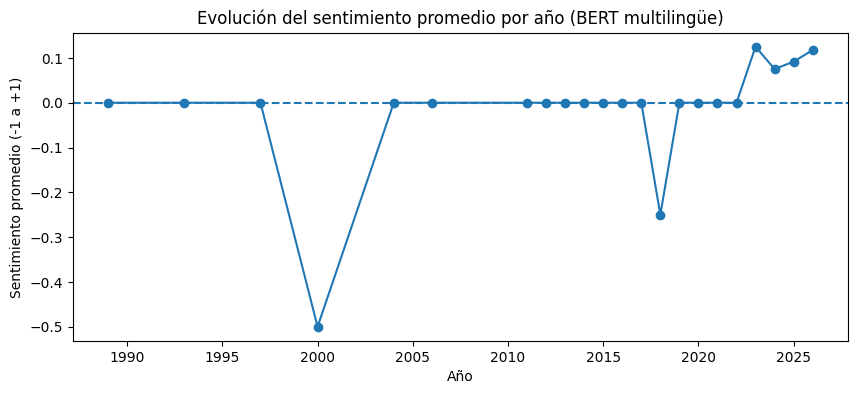

'sentiment_over_time.png'

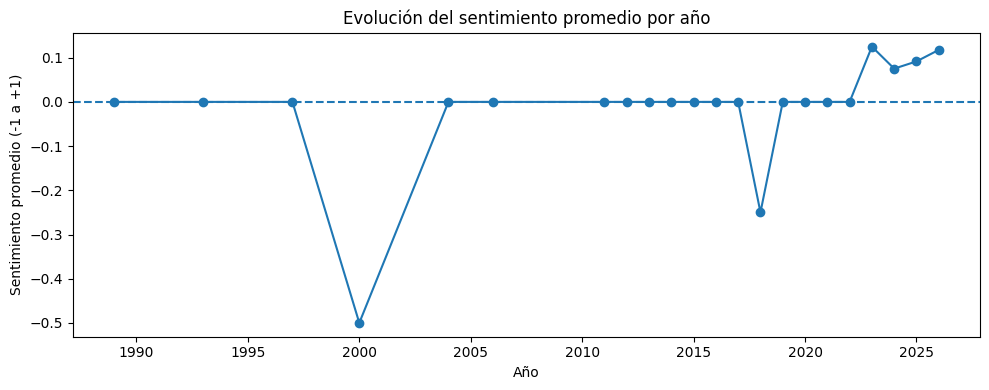

In [ ]:
# 3) Evolución del sentimiento promedio por año
sent_by_year = df_s.groupby("year")["sent_score"].mean().reset_index().sort_values("year")

plt.figure(figsize=(10,4))
plt.plot(sent_by_year["year"], sent_by_year["sent_score"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Evolución del sentimiento promedio por año (BERT multilingüe)")
plt.xlabel("Año")
plt.ylabel("Sentimiento promedio (-1 a +1)")
plt.show()

# Guardar figura para el informe LaTeX
out_fig = "sentiment_over_time.png"
plt.figure(figsize=(10,4))
plt.plot(sent_by_year["year"], sent_by_year["sent_score"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Evolución del sentimiento promedio por año")
plt.xlabel("Año")
plt.ylabel("Sentimiento promedio (-1 a +1)")
plt.tight_layout()
plt.savefig(out_fig, dpi=200)
out_fig


## 4) LLM open source (ligero) para análisis de contexto
Modelo sugerido: Qwen/Qwen2-1.5B-Instruct


In [ ]:
llm_name = "Qwen/Qwen2-1.5B-Instruct"

tok = AutoTokenizer.from_pretrained(llm_name)
llm = AutoModelForCausalLM.from_pretrained(
    llm_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)

gen = pipeline("text-generation", model=llm, tokenizer=tok, device=device)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
# 1) Copia segura
df_s = df_s.copy()
df_s["abstract"] = df_s["abstract"].astype(str)

# 2) Filtro: educación + IA generativa/LLM
mask = (
    df_s["abstract"].str.contains(
        "education|teaching|learning|classroom|students|higher education|pedagog|assessment|curriculum",
        case=False, na=False
    )
    & df_s["abstract"].str.contains(
        "chatgpt|gpt|large language model|llm|generative ai|genai",
        case=False, na=False
    )
    & ~df_s["abstract"].str.contains(  # excluye medicina típica
        "patient|clinical|disease|treatment|diagnostic|surgery|urology|hemodialysis|thalas",
        case=False, na=False
    )
)

df_f = df_s[mask].copy()

# Si quedan pocos, usa df_s como respaldo (pero idealmente df_f debe tener bastantes)
if len(df_f) < 20:
    df_f = df_s.copy()

# 3) Elegir abstracts representativos por longitud
df_f["abstract_len"] = df_f["abstract"].str.len()
df_top = df_f.sort_values("abstract_len", ascending=False).head(6)

context = "\n\n".join([f"- {t[:800]}" for t in df_top["abstract"].tolist()])

# 4) Prompt LLM (estratégico)
prompt = f"""Eres un analista de inteligencia estratégica para negocios.
Con base en los siguientes abstracts de artículos científicos, produce un informe con:
1) Barreras de adopción (técnicas, regulatorias, económicas, organizacionales).
2) Aplicaciones futuras con potencial de mercado.
3) Tendencias de investigación (temas recurrentes) y justificación.
4) Recomendaciones para una empresa que quiera invertir/adoptar en 24 meses.

Abstracts:
{context}
"""

out = gen(prompt, max_new_tokens=250, do_sample=True, temperature=0.3)[0]["generated_text"]
print(out)

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Eres un analista de inteligencia estratégica para negocios.
Con base en los siguientes abstracts de artículos científicos, produce un informe con:
1) Barreras de adopción (técnicas, regulatorias, económicas, organizacionales).
2) Aplicaciones futuras con potencial de mercado.
3) Tendencias de investigación (temas recurrentes) y justificación.
4) Recomendaciones para una empresa que quiera invertir/adoptar en 24 meses.

Abstracts:
- In July 2023, given the rise of LLMs (Large Langauge Models), RED convened this special issue on Generative AI and Education, where special attention was paid to its consequences for intelligent learning and educational evaluation. We wanted to give space to contributions that included research related to these topics. Also to experiences about intelligent learning and formative evaluation in ChatGPT contexts. The call was with these general questions • Does AI have the potential to revolutionize existing teaching methods, assessment and student support? • C

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

CSV_META = "/content/drive/MyDrive/FASE3/scopus_export.csv"  # ajusta
df = pd.read_csv(CSV_META)

# Normalizar columnas
df = df.rename(columns={"Year":"year","Abstract":"abstract"}).copy()
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["abstract"] = df["abstract"].astype(str).fillna("")
df = df.dropna(subset=["year"])
df = df[df["abstract"].str.len() > 30]

# Filtro del trabajo
df = df[(df["year"]>=2020) & (df["year"]<=2026)].copy()

df.shape, df[["year","abstract"]].head(3)

Mounted at /content/drive


((316, 12),
    year                                           abstract
 0  2025  The emergence of generative artificial intelli...
 1  2025  This article analyses the regulatory and ethic...
 2  2024  Introduction: Artificial intelligence (AI), th...)

In [2]:
print("Total registros (2020–2026):", df.shape[0])
print("Años en el dataset:", sorted(df["year"].unique())[:10], "...", sorted(df["year"].unique())[-10:])

Total registros (2020–2026): 316
Años en el dataset: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)] ... [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [3]:
print("Columnas:", df.columns.tolist())


Columnas: ['Authors', 'Author full names', 'Author(s) ID', 'year', 'Source title', 'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'abstract', 'Author Keywords']


Problemática de negocio (IA generativa en educación)
Las instituciones educativas (universidades y colegios) están bajo presión para incorporar herramientas de IA generativa (p. ej., ChatGPT/LLMs) en procesos de enseñanza-aprendizaje, pero enfrentan riesgos relevantes: integridad académica (plagio/uso indebido en evaluaciones), privacidad de datos, sesgos, y ausencia de lineamientos claros. Al mismo tiempo, existen oportunidades de valor: tutoría personalizada, retroalimentación formativa, apoyo al diseño instruccional y mejora de productividad docente.

Pregunta de negocio: ¿Cómo está evolucionando la evidencia científica (temas dominantes + tono del discurso) sobre IA generativa en educación y qué tendencia de crecimiento de publicaciones se espera, para orientar decisiones de adopción responsable en los próximos 24 meses?

Decisión a soportar con el análisis: Definir si conviene (i) mantener adopción limitada, (ii) escalar pilotos controlados, o (iii) institucionalizar la adopción con políticas, capacitación y rediseño de evaluación.

Nota: el corpus bibliométrico (Biblioshiny) contiene 344 registros importados; para NLP/ML en Colab se trabajó con 316 registros (2020–2026) tras limpieza y disponibilidad de abstracts

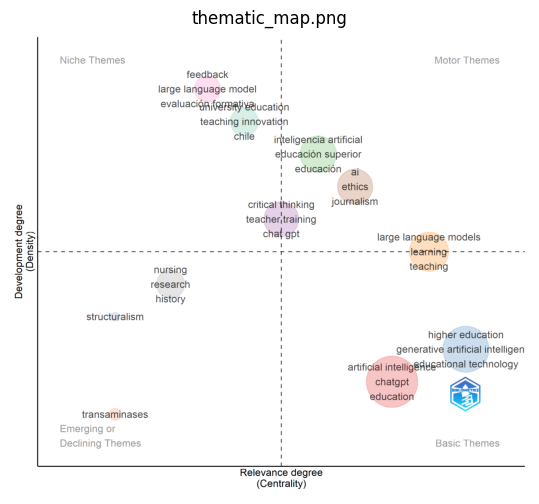

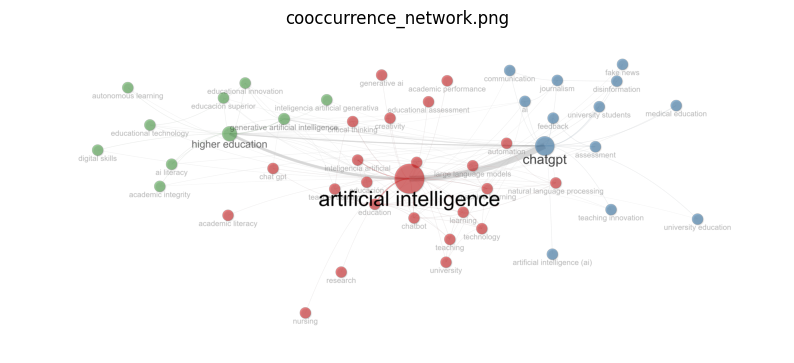

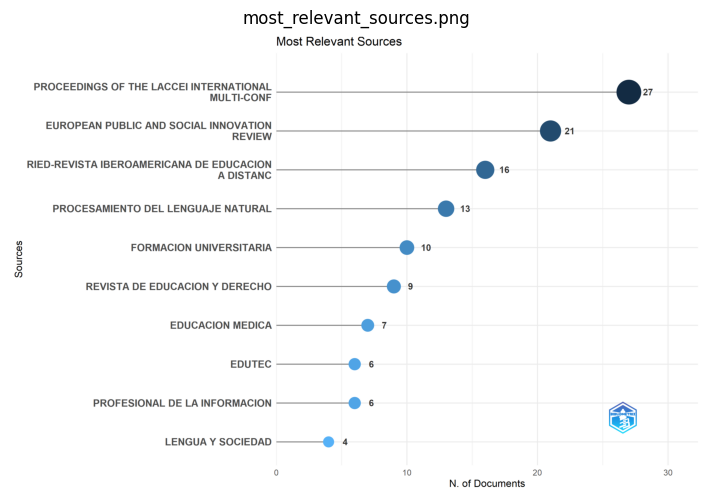

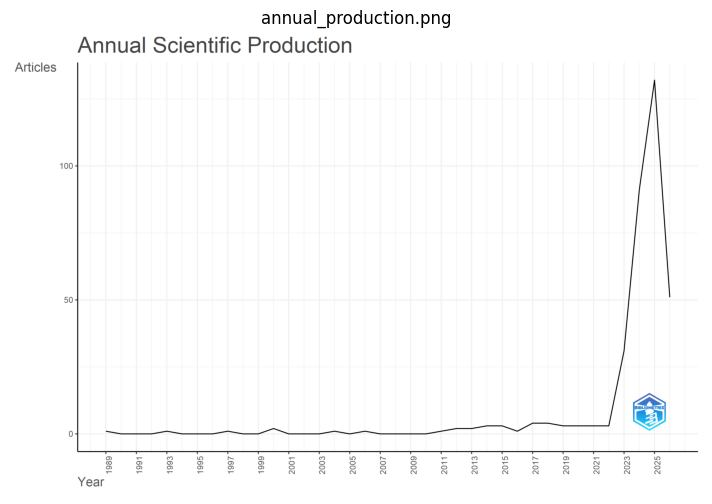

In [7]:
import os
from PIL import Image
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/FASE3/outputs"

imgs = [
    "thematic_map.png",
    "cooccurrence_network.png",
    "most_relevant_sources.png",
    "annual_production.png",
]

for fn in imgs:
    path = os.path.join(OUT_DIR, fn)
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(10,6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(fn)
        plt.show()
    else:
        print("No encuentro:", path)

In [8]:
from PIL import Image
import os

OUT_DIR = "/content/drive/MyDrive/FASE3/outputs"

for fn in imgs:
    png_path = os.path.join(OUT_DIR, fn)
    pdf_path = os.path.join(OUT_DIR, fn.replace(".png", ".pdf"))
    if os.path.exists(png_path):
        img = Image.open(png_path).convert("RGB")
        img.save(pdf_path)
        print("PDF creado:", pdf_path)

PDF creado: /content/drive/MyDrive/FASE3/outputs/thematic_map.pdf
PDF creado: /content/drive/MyDrive/FASE3/outputs/cooccurrence_network.pdf
PDF creado: /content/drive/MyDrive/FASE3/outputs/most_relevant_sources.pdf
PDF creado: /content/drive/MyDrive/FASE3/outputs/annual_production.pdf


Bibliometría (Bibliometrix/Biblioshiny)
Se importaron 344 documentos desde Scopus en Biblioshiny. Se generaron: (i) mapa temático (Author’s Keywords) para identificar temas básicos y especializados; (ii) red de co-ocurrencia de términos para observar clusters conceptuales; (iii) fuentes más relevantes para identificar dónde se publica el conocimiento; y (iv) producción anual para evidenciar tendencia temporal. Los gráficos se exportaron en PNG/PDF y se integran como evidencia del análisis.

## 5) Exportables para LaTeX
- Copia `sentiment_over_time.png` a la carpeta `figures/` del proyecto LaTeX.
- Copia el texto del LLM a la sección “Síntesis estratégica (LLM)”.
